# Automated Casting Defect Detection Using a CNN
Binary classification: `ok_front` = 0 (non-defective), `def_front` = 1 (defective).
Custom CNN + Xception transfer learning, 70/30 train-test split.

In [8]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Dataset

In [9]:
train_directory = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train"
test_directory = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test"

print("Train directory:", train_directory)
print("Test directory: ", test_directory)


Train directory: /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train
Test directory:  /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test


In [10]:
class_names = ["ok_front", "def_front"]

def count_images(directory):
    counts = {}
    for cls in class_names:
        folder = os.path.join(directory, cls)
        counts[cls] = len(glob.glob(os.path.join(folder, "*")))
    return counts

train_counts = count_images(train_directory)
test_counts = count_images(test_directory)

print("Training folder counts:", train_counts)
print("Test folder counts:    ", test_counts)

summary_df = pd.DataFrame({"train": train_counts, "test": test_counts})
summary_df["total"] = summary_df["train"] + summary_df["test"]
summary_df


Training folder counts: {'ok_front': 2875, 'def_front': 3758}
Test folder counts:     {'ok_front': 262, 'def_front': 453}


,train,test,total
ok_front,2875,262,3137
def_front,3758,453,4211


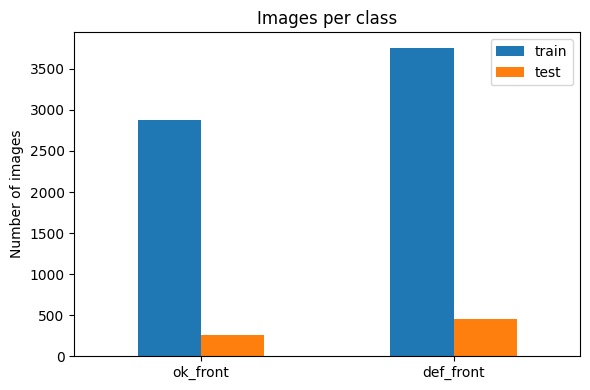

Defective share of training data: 56.7%


In [11]:
# Class balance
fig, ax = plt.subplots(figsize=(6, 4))
summary_df[["train", "test"]].plot(kind="bar", ax=ax)
ax.set_title("Images per class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

train_ratio = train_counts["def_front"] / sum(train_counts.values())
print(f"Defective share of training data: {train_ratio:.1%}")


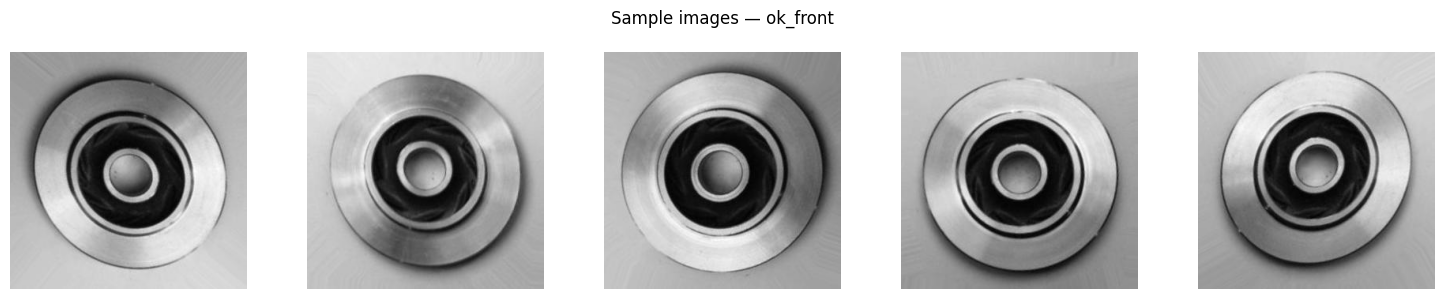

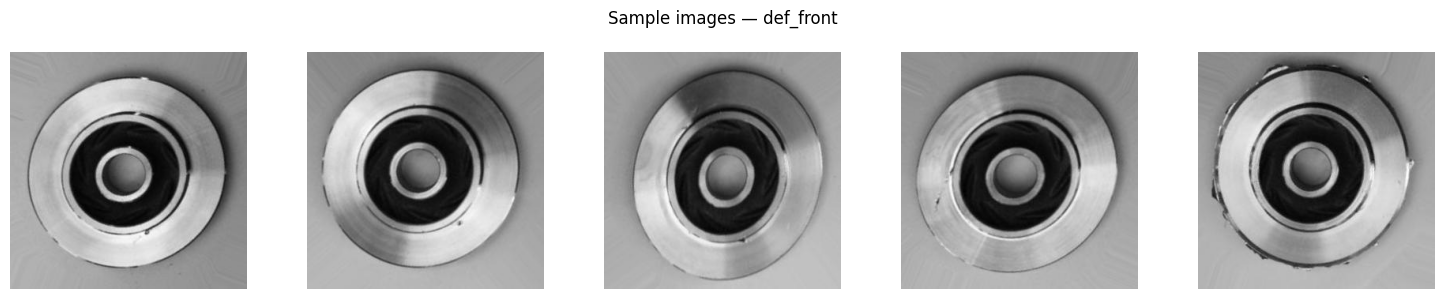

In [12]:
# Display sample images from each class
def show_samples(directory, cls, n=5):
    folder = os.path.join(directory, cls)
    files = random.sample(os.listdir(folder), n)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, fname in zip(axes, files):
        img = tf.keras.utils.load_img(os.path.join(folder, fname))
        ax.imshow(img)
        ax.axis("off")
    fig.suptitle(f"Sample images — {cls}")
    plt.tight_layout()
    plt.show()

show_samples(train_directory, "ok_front")
show_samples(train_directory, "def_front")


## 2. Data Preparation — 70/30 Train-Test Split

In [13]:
image_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.


I0000 00:00:1786376902.658702      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


## 3. Data Augmentation (training data only)

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")


## 4. Custom CNN

In [15]:
manual_cnn = model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.40),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(1, activation="sigmoid"),
    ], name="manual_cnn")

manual_cnn.summary()

Model: "manual_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
manual_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)

manual_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint("best_manual_cnn.keras", monitor="val_loss", save_best_only=True),
]

manual_cnn_history = manual_cnn.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=25,
    callbacks=manual_callbacks,
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.5604 - loss: 0.6881 - precision: 0.5607 - recall: 0.9980 - val_accuracy: 0.6336 - val_loss: 0.6675 - val_precision: 0.6336 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5608 - loss: 0.6855 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.6336 - val_loss: 0.6726 - val_precision: 0.6336 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5606 - loss: 0.6835 - precision: 0.5616 - recall: 0.9862 - val_accuracy: 0.6336 - val_loss: 0.6489 - val_precision: 0.6336 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5755 - loss: 0.6741 - precision: 0.5801 - recall: 0.8794 - val_accuracy: 0.7385 - val_loss: 0.6195 - val_precision: 0.7166 - val_recall: 0.9713 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accu

## 5. Training Curves

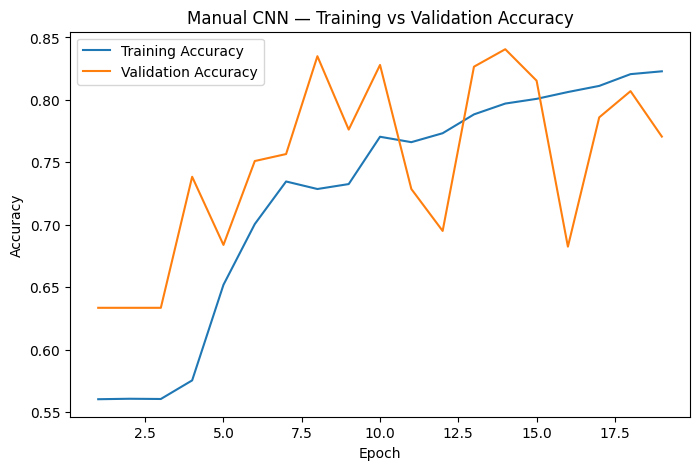

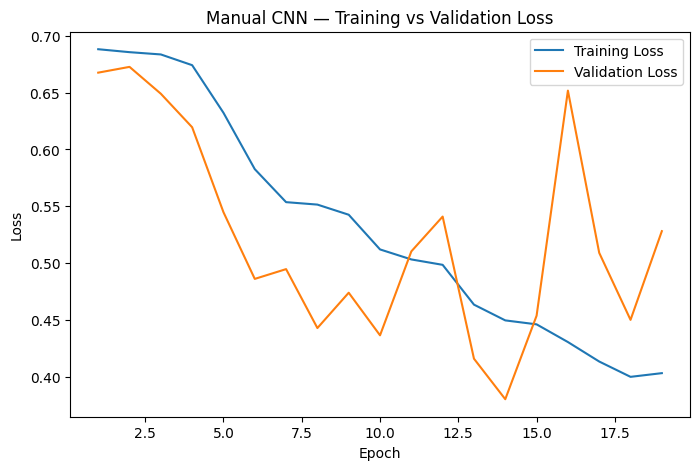

In [17]:
def plot_history(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}Training vs Validation Accuracy")
    plt.legend(); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{title_prefix}Training vs Validation Loss")
    plt.legend(); plt.show()

plot_history(manual_cnn_history, title_prefix="Manual CNN — ")


## 6. Evaluate Custom CNN

--- Manual CNN ---
               precision    recall  f1-score   support

Non-defective       0.86      0.68      0.76       262
    Defective       0.83      0.94      0.88       453

     accuracy                           0.84       715
    macro avg       0.85      0.81      0.82       715
 weighted avg       0.84      0.84      0.84       715



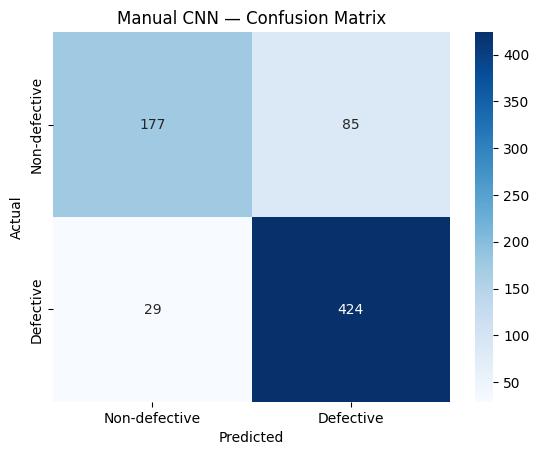

In [18]:
def evaluate_model(model, dataset, name):
    probs = model.predict(dataset, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    actual = np.concatenate([y.numpy().flatten() for _, y in dataset]).astype(int)

    print(f"--- {name} ---")
    print(classification_report(actual, preds, target_names=["Non-defective", "Defective"]))

    cm = confusion_matrix(actual, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-defective", "Defective"], yticklabels=["Non-defective", "Defective"])
    plt.title(f"{name} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()
    return probs, actual

manual_probs, actual_labels = evaluate_model(manual_cnn, test_dataset, "Manual CNN")

## 7. Predict on Unseen Images

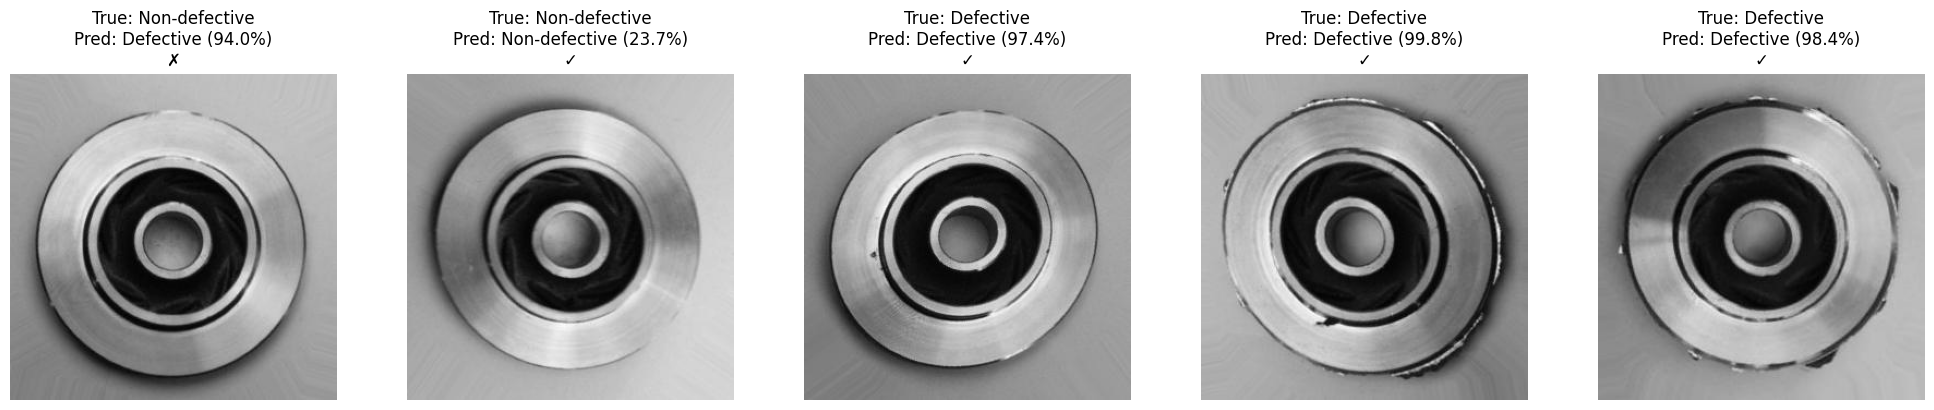

In [21]:
# Sample 5 unseen images (2-3 from each test class) and check them one by one
sample_paths = []
for cls, true_label in [("ok_front", "Non-defective"), ("def_front", "Defective")]:
    folder = os.path.join(test_directory, cls)
    files = random.sample(os.listdir(folder), 3 if cls == "def_front" else 2)
    sample_paths += [(os.path.join(folder, f), true_label) for f in files]

fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 4))
for ax, (path, true_label) in zip(axes, sample_paths):
    prob, pred = predict_product(path, manual_cnn)
    correct = "✓" if pred == true_label else "✗"
    img = tf.keras.utils.load_img(path)
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred} ({prob:.1%})\n{correct}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Xception Transfer Learning

In [22]:
from tensorflow.keras.applications.xception import Xception, preprocess_input

def build_xception_model(trainable_base=False):
    base_model = Xception(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3),
    )
    base_model.trainable = trainable_base

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="xception_transfer")
    return model, base_model

xception_model, xception_base = build_xception_model(trainable_base=False)
xception_model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "xception_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,992,681 (80.08 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [24]:
xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

xception_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_casting_defect_xception_stage1.keras",
        monitor="val_loss", save_best_only=True,
    ),
]

xception_history = xception_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=xception_callbacks,
)

Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 32s 155ms/step - accuracy: 0.8690 - loss: 0.3069 - precision: 0.8808 - recall: 0.8864 - val_accuracy: 0.9404 - val_loss: 0.1621 - val_precision: 0.9958 - val_recall: 0.9028 - learning_rate: 0.0010
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.9299 - loss: 0.1719 - precision: 0.9438 - recall: 0.9304 - val_accuracy: 0.9713 - val_loss: 0.0891 - val_precision: 0.9882 - val_recall: 0.9629 - learning_rate: 0.0010
Epoch 3/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.9423 - loss: 0.1497 - precision: 0.9532 - recall: 0.9435 - val_accuracy: 0.9661 - val_loss: 0.1035 - val_precision: 0.9986 - val_recall: 0.9437 - learning_rate: 0.0010
Epoch 4/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.9478 - loss: 0.1363 - precision: 0.9589 - recall: 0.9476 - val_accuracy: 0.9789 - val_loss: 0.0687 - val_precision: 0.9748 - val_recall: 0.9898 - learning_rate: 0.0010
Epoch 5/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/st

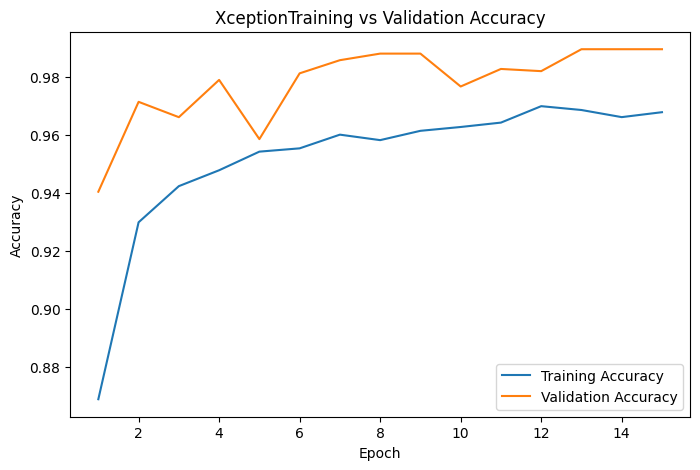

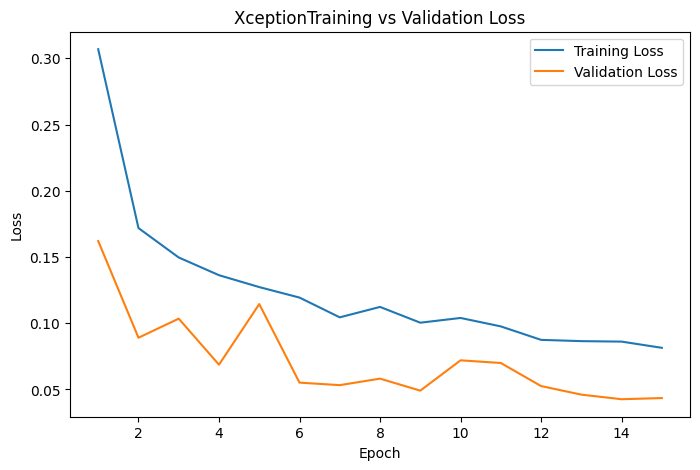

In [25]:
plot_history(xception_history, "Xception")

## 9. Evaluate Xception

--- Xception ---
               precision    recall  f1-score   support

Non-defective       0.98      0.99      0.98       262
    Defective       0.99      0.99      0.99       453

     accuracy                           0.99       715
    macro avg       0.99      0.99      0.99       715
 weighted avg       0.99      0.99      0.99       715



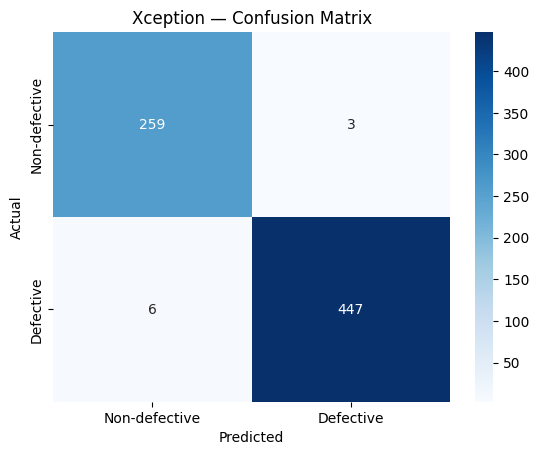

In [26]:
xception_probs, _ = evaluate_model(xception_model, test_dataset, "Xception")

## 10.Predict on the Same Unseen Images with Xception

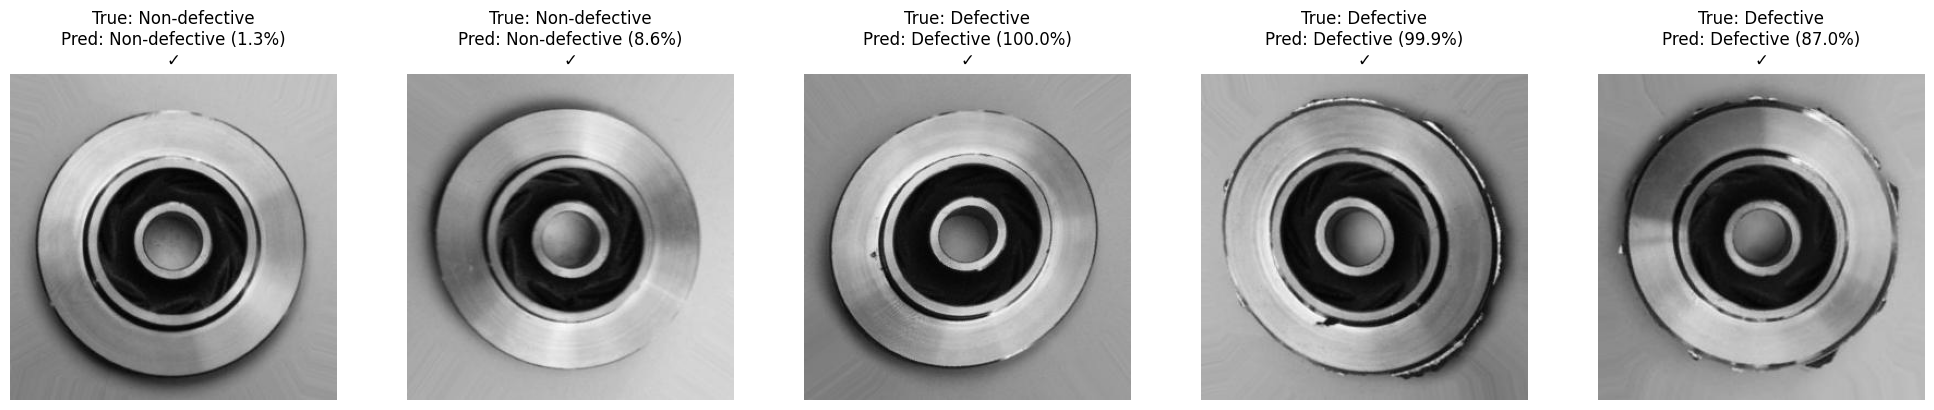

In [29]:
fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 4))
for ax, (path, true_label) in zip(axes, sample_paths):
    prob, pred = predict_product(path, xception_model)
    correct = "✓" if pred == true_label else "✗"
    img = tf.keras.utils.load_img(path)
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred} ({prob:.1%})\n{correct}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 11. Save Models

In [ ]:
manual_cnn.save("final_manual_cnn.keras")
xception_model.save("final_xception_model.keras")
print("Saved final_manual_cnn.keras and final_xception_model.keras")